### Replacing Fourier Bank using a FNO-type layer

For Elliptical domain equation.

In [13]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1

Found existing installation: torch 2.5.1
Uninstalling torch-2.5.1:
  Successfully uninstalled torch-2.5.1
Found existing installation: torchvision 0.20.1
Uninstalling torchvision-0.20.1:
  Successfully uninstalled torchvision-0.20.1
Found existing installation: torchaudio 2.5.1
Uninstalling torchaudio-2.5.1:
  Successfully uninstalled torchaudio-2.5.1
  Using cached torch-2.5.1-cp312-cp312-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached torchvision-0.20.1-cp312-cp312-manylinux1_x86_64.whl.metadata (6.1 kB)
  Using cached torchaudio-2.5.1-cp312-cp312-manylinux1_x86_64.whl.metadata (6.4 kB)
Using cached torch-2.5.1-cp312-cp312-manylinux1_x86_64.whl (906.4 MB)
Using cached torchvision-0.20.1-cp312-cp312-manylinux1_x86_64.whl (7.2 MB)
Using cached torchaudio-2.5.1-cp312-cp312-manylinux1_x86_64.whl (3.4 MB)


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt
from time import time
import os

f_set = [ 600, 900, 1200 ]
c = 343.0
k_set = [ ( 2.0 * np.pi * f ) / c for f in f_set ]

Nf = 6400
adam_epochs = 2000

torch.set_default_dtype ( torch.float64 )
device = torch.device ( "cuda" if torch.cuda.is_available() else "cpu" )
print ( "Active Hardware Target:", device )

class FNOBlock1D ( nn.Module ):
    def __init__ ( self, latent_dim = 128, modes = 64 ):
        super().__init__()
        self.latent_dim = latent_dim
        self.modes = modes
        
        scale = 1.0 / ( latent_dim * modes )
        self.complex_weights = nn.Parameter (
            scale * torch.randn ( 1, modes, dtype = torch.cdouble )
        )
        
        self.skip_layer = nn.Linear ( latent_dim, latent_dim )
        
    def forward ( self, x ):
        x_ft = torch.fft.rfft ( x, dim = -1 )
        out_ft = torch.zeros_like ( x_ft )
        out_ft[:, :self.modes] = x_ft[:, :self.modes] * self.complex_weights
        x_fourier = torch.fft.irfft ( out_ft, n = self.latent_dim, dim = -1 )
        
        x_skip = self.skip_layer ( x )
        
        return F.gelu ( x_fourier + x_skip )

class DeepIsolatedBranch ( nn.Module ):
    def __init__ ( self, n_fno_blocks = 4, hidden_dim = 128, fno_modes = 64, out_modes = 64 ):
        super().__init__()
        
        self.lifting = nn.Linear ( 1, hidden_dim )
        
        self.fno_chain = nn.ModuleList ( [
            FNOBlock1D ( latent_dim = hidden_dim, modes = fno_modes )
            for _ in range ( n_fno_blocks )
        ] )
        
        self.projection = nn.Sequential (
            nn.Linear ( hidden_dim, hidden_dim ),
            nn.GELU(),
            nn.Linear ( hidden_dim, out_modes )
        )
        
    def forward ( self, coord ):
        x = self.lifting ( coord )
        
        for block in self.fno_chain:
            x = block ( x )
            
        return self.projection ( x )

class Separable_FNO_PINN ( nn.Module ):
    def __init__ ( self, n_fno_blocks = 4, hidden_dim = 128, fno_modes = 64, tensor_modes = 64 ):
        super().__init__()

        self.network_X = DeepIsolatedBranch ( n_fno_blocks, hidden_dim, fno_modes, tensor_modes )
        self.network_Y = DeepIsolatedBranch ( n_fno_blocks, hidden_dim, fno_modes, tensor_modes )
        
        self.apply ( self.init_weights )

    def init_weights ( self, m ):
        if isinstance ( m, nn.Linear ):
            torch.nn.init.xavier_uniform_ ( m.weight )
            if m.bias is not None:
                m.bias.data.fill_ ( 0.0 )

    def forward ( self, xy ):
        x = xy[:, 0:1]
        y = xy[:, 1:2]

        X_out = self.network_X ( x )
        Y_out = self.network_Y ( y )
        
        network_out = torch.sum ( X_out * Y_out, dim = -1, keepdim = True )
        
        a = 1.0
        b = 0.5
        
        phi_e = ( 1.0 - ( ( x / a )**2 + ( y / b )**2 ) ) / 2.0
        
        W = 1.0 - phi_e
        
        psi_R = 1.0
        
        psi_t = W * psi_R + phi_e * network_out
        
        return psi_t
        
def net_loss ( model, xy, k, return_pointwise = False ):
    p = model ( xy )
    
    dp_dxy = torch.autograd.grad (
        p, xy, grad_outputs = torch.ones_like ( p ),
        create_graph = True, retain_graph = True
    )[0]
    dp_dx = dp_dxy[:, 0:1]
    dp_dy = dp_dxy[:, 1:2]
    
    d2p_dx2 = torch.autograd.grad (
        dp_dx, xy, grad_outputs = torch.ones_like ( dp_dx ),
        create_graph = True, retain_graph = True
    )[0][:, 0:1]
    
    d2p_dy2 = torch.autograd.grad (
        dp_dy, xy, grad_outputs = torch.ones_like ( dp_dy ),
        create_graph = True, retain_graph = True
    )[0][:, 1:2]
    
    residual = ( d2p_dx2 + d2p_dy2 ) / ( k**2 ) + p

    if return_pointwise:
        return torch.abs ( residual )
    return torch.mean ( residual**2 )

def sample_ellipse ( num_points, a = 1.0, b = 0.5 ):
    r = torch.sqrt ( torch.rand ( num_points, 1, device = device ) )
    theta = torch.rand ( num_points, 1, device = device ) * 2.0 * np.pi
    return torch.cat ( [ a * r * torch.cos ( theta ), b * r * torch.sin ( theta ) ], dim = 1 )

xy_f_base = sample_ellipse ( Nf )

models = []
loss_histories = []

model = Separable_FNO_PINN().to ( device )

start = time()

for i, k in enumerate ( k_set ):
    
    xy_f = xy_f_base.clone()
    xy_f.requires_grad = True

    adam_opt = torch.optim.Adam ( model.parameters(), lr = 0.001, weight_decay = 1e-5 )

    loss_history = []

    print ( f"INFO: Adam Training Started For f = {f_set[i]} Hz" )    
    for epoch in range ( adam_epochs ):
        adam_opt.zero_grad()
        loss = net_loss ( model, xy_f, k )
        loss.backward()
        adam_opt.step()
        
        loss_history.append ( loss.item() )
        
        if ( epoch + 1 ) % 200 == 0:
            with torch.no_grad():
                xy_candidate = sample_ellipse ( 5000 )
            xy_candidate.requires_grad = True
            
            abs_residual = net_loss ( model, xy_candidate, k, return_pointwise = True )
            
            _, top_indices = torch.topk ( abs_residual.flatten(), 50 )
            xy_f = torch.cat ( [ xy_f.detach(), xy_candidate[top_indices].detach() ], dim = 0 )
            xy_f.requires_grad = True
            print ( f"INFO: f = {f_set[i]} Hz; Iteration: {len(loss_history)}; Loss: {loss.item():.6e}; Time: {time() - start:.2f}s" )

    print ( f"INFO: Adam Training Done For f = {f_set[i]} Hz\n" )

    define_iters = 5000

    opt = torch.optim.LBFGS (
        model.parameters(),
        lr = 1.0,
        max_iter = define_iters,
        line_search_fn = "strong_wolfe" )

    def closure():
        opt.zero_grad()
        loss = net_loss ( model, xy_f, k )
        loss.backward()
        
        loss_history.append ( loss.item() )
        if len ( loss_history ) % 1000 == 0:
            print ( f"INFO: Iteration: {len(loss_history)}; Loss: {loss.item():.6e}; Time: {time() - start:.2f}s" )
        return loss

    print ( f"INFO: LBFGS Training Started For f = {f_set[i]} Hz\n" )
    opt.step ( closure )
    print ( f"INFO: LBFGS Training Done For f = {f_set[i]} Hz\n" )
    
    models.append ( copy.deepcopy ( model ) )
    loss_histories.append ( loss_history )


Active Hardware Target: cuda
INFO: Adam Training Started For f = 600 Hz
INFO: f = 600 Hz; Iteration: 200; Loss: 1.170653e-01; Time: 27.85s
INFO: f = 600 Hz; Iteration: 400; Loss: 1.064441e-02; Time: 55.92s
INFO: f = 600 Hz; Iteration: 600; Loss: 3.928245e-03; Time: 84.20s
INFO: f = 600 Hz; Iteration: 800; Loss: 2.245451e-04; Time: 112.60s
INFO: f = 600 Hz; Iteration: 1000; Loss: 8.528604e-05; Time: 141.18s
INFO: f = 600 Hz; Iteration: 1200; Loss: 5.346907e-05; Time: 169.92s
INFO: f = 600 Hz; Iteration: 1400; Loss: 3.965546e-05; Time: 199.03s
INFO: f = 600 Hz; Iteration: 1600; Loss: 7.093965e-05; Time: 228.27s
INFO: f = 600 Hz; Iteration: 1800; Loss: 2.320210e-05; Time: 257.70s
INFO: f = 600 Hz; Iteration: 2000; Loss: 1.963785e-05; Time: 287.29s
INFO: Adam Training Done For f = 600 Hz

INFO: LBFGS Training Started For f = 600 Hz

INFO: LBFGS Training Done For f = 600 Hz

INFO: Adam Training Started For f = 900 Hz
INFO: f = 900 Hz; Iteration: 200; Loss: 3.921778e-02; Time: 369.76s
INFO: 

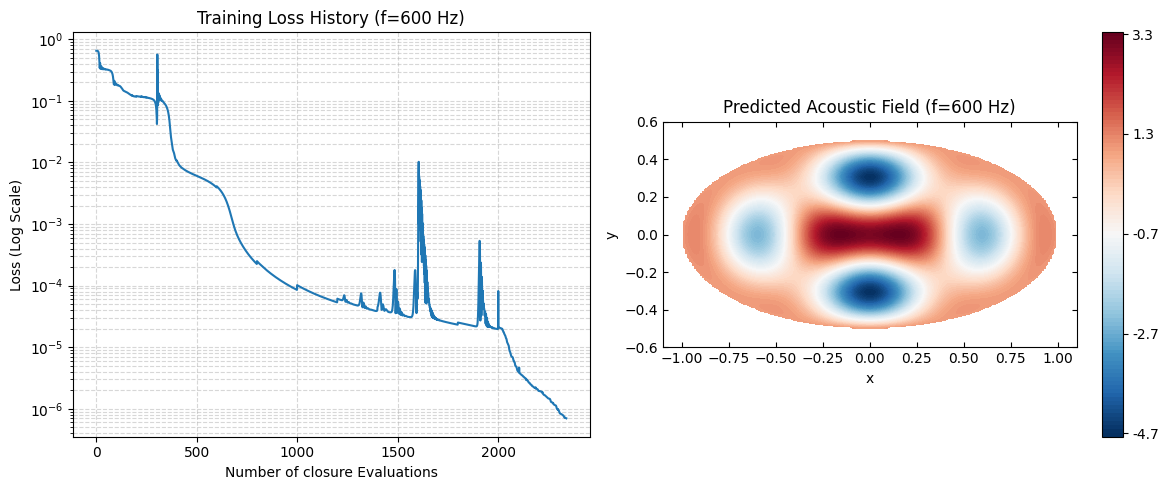

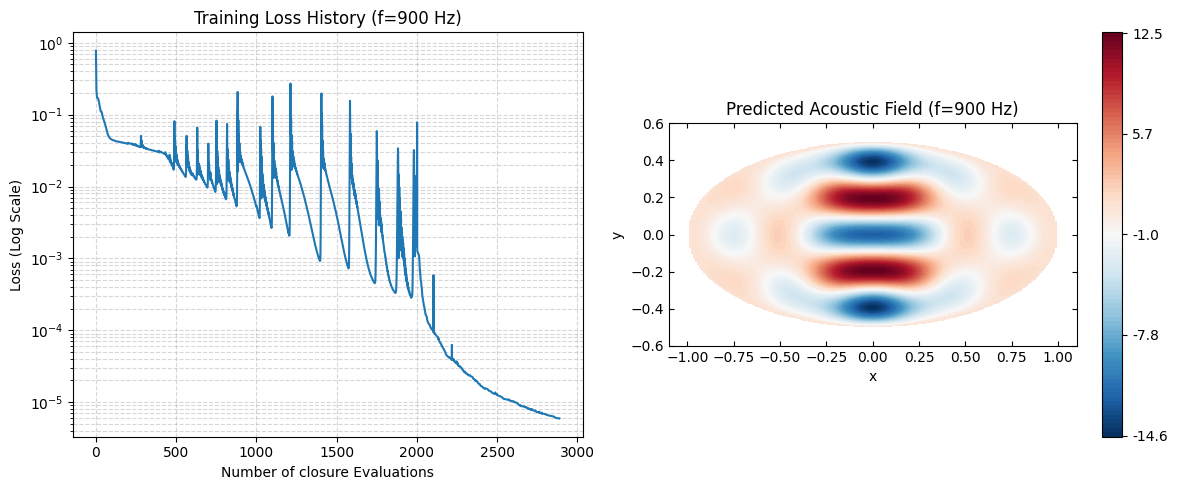

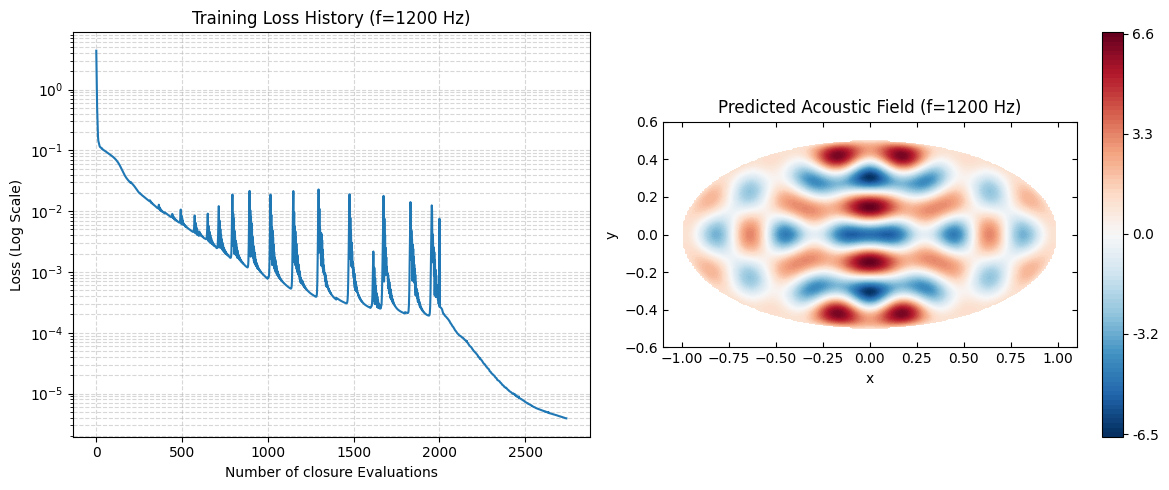

In [31]:
for idx, k in enumerate ( k_set ): 
    with torch.no_grad():
        x_plot = np.linspace ( -1.1, 1.1, 200 )
        y_plot = np.linspace ( -0.6, 0.6, 200 )
        X, Y = np.meshgrid ( x_plot, y_plot )
        xy_plot = torch.tensor ( np.column_stack ( ( X.flatten(), Y.flatten() ) ), dtype = torch.float64, device = device )
        
        pred_p = models[idx]( xy_plot )
        pred_p = pred_p.cpu().numpy().reshape ( 200, 200 )

    a, b = 1.0, 0.5
    mask = ( ( X / a )**2 + ( Y / b )**2 ) > 1.0
    pred_p[mask] = np.nan

    fig, axs = plt.subplots ( 1, 2, figsize = ( 12, 5 ) )

    axs[0].plot ( loss_histories[idx] )
    axs[0].set_yscale ( "log" )
    axs[0].set_xlabel ( "Number of closure Evaluations" )
    axs[0].set_ylabel ( "Loss (Log Scale)" )
    axs[0].set_title ( f"Training Loss History (f={f_set[idx]} Hz)" )
    axs[0].grid ( True, which = "both", linestyle = "--", alpha = 0.5 )

    p_min = np.nanmin ( pred_p )
    p_max = np.nanmax ( pred_p )

    c1 = axs[1].contourf ( X, Y, pred_p, 100, cmap = 'RdBu_r', vmin = p_min, vmax = p_max )
    
    cb_ticks = np.linspace ( p_min, p_max, 5 )
    cb = fig.colorbar ( c1, ax = axs[1], ticks = cb_ticks )
    cb.ax.set_yticklabels ( [ f'{val:.1f}' for val in cb_ticks ] )
    
    axs[1].set_title ( f"Predicted Acoustic Field (f={f_set[idx]} Hz)" )
    axs[1].set_xlabel ( "x" )
    axs[1].set_ylabel ( "y" )
    
    axs[1].set_aspect ( 'equal', 'box' )
    axs[1].tick_params ( direction = 'in', top = True, right = True )

    plt.tight_layout()
    plt.show()